# exp-profile-model-01 — 클래스별 mutation-profile 모델

## 목적
기존 08-spec LR과 다른 확률 원리로 암종별 전형 mutation profile과의 유사도를 계산한다. 단독 성능뿐 아니라 LR 확률과의 고정 blend가 다른 오류를 보완하는지 확인한다.

### 후보
- Bernoulli NB: 변이 발생/비발생 프로필
- Complement NB: 클래스 불균형을 보완한 count profile
- Multinomial NB: 비음수 event count profile
- Prototype cosine: 암종별 평균 mutation profile과의 cosine 유사도

### 고정 규칙
seed 42, Stratified 5-fold, alpha=1.0, prototype temperature=0.10, profile blend `0.25 / 0.50`만 비교한다. 모든 profile·event 선택·LR 피팅은 fold-train만 사용하며 test.csv를 읽지 않는다.


In [1]:
from pathlib import Path
import subprocess, sys
import pandas as pd
import matplotlib.pyplot as plt

def find_exp_model():
    for path in (Path.cwd(), *Path.cwd().parents):
        direct = path / 'common' / 'exp_profile_model_runner.py'
        project = path / 'experiments' / 'gs' / 'notebooks' / 'exp_model' / 'common' / 'exp_profile_model_runner.py'
        if direct.exists(): return path
        if project.exists(): return project.parent.parent
    raise FileNotFoundError('profile-model runner를 찾지 못했습니다.')

EXP_MODEL = find_exp_model()
RUNNER = EXP_MODEL / 'common' / 'exp_profile_model_runner.py'
RESULT_DIR = EXP_MODEL / 'result'
RUN_ID = 'exp-profile-model-01'
SEED = 42
RUN_EXPERIMENT = True
print({'runner': RUNNER, 'seed': SEED, 'models': ['bernoulli_nb', 'complement_nb', 'multinomial_nb', 'prototype_cosine']})


{'runner': PosixPath('/Users/admin/Documents/FinalProject/OZ_fianl_hackaton/experiments/gs/notebooks/exp_model/common/exp_profile_model_runner.py'), 'seed': 42, 'models': ['bernoulli_nb', 'complement_nb', 'multinomial_nb', 'prototype_cosine']}


In [2]:
if RUN_EXPERIMENT:
    command = [sys.executable, str(RUNNER), '--seed', str(SEED), '--run-id', RUN_ID]
    process = subprocess.Popen(command, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1)
    assert process.stdout is not None
    tail = []
    for line in process.stdout:
        print(line, end='')
        tail = (tail + [line])[-80:]
    return_code = process.wait()
    if return_code:
        raise RuntimeError(f'profile-model runner failed (exit={return_code}). Last output:\n' + ''.join(tail))



row-local mutation cache: 100%|██████████| 4384/4384 [00:11<00:00, 369.05it/s]

profile-model | seed 42:   0%|          | 0/5 [00:00<?, ?fold/s]
profile-model | seed 42:  20%|██        | 1/5 [00:06<00:27,  6.84s/fold]
profile-model | seed 42:  40%|████      | 2/5 [00:13<00:19,  6.49s/fold]
profile-model | seed 42:  60%|██████    | 3/5 [00:19<00:12,  6.44s/fold]
profile-model | seed 42:  80%|████████  | 4/5 [00:25<00:06,  6.47s/fold]
profile-model | seed 42: 100%|██████████| 5/5 [00:32<00:00,  6.41s/fold]
profile-model | seed 42: 100%|██████████| 5/5 [00:32<00:00,  6.46s/fold]
[
  {
    "experiment_id":"exp-profile-model-01",
    "model":"lr08_baseline",
    "seed":42,
    "profile_oof_macro_f1":0.4825927952,
    "blend_weight_profile":0.0,
    "blend_oof_macro_f1":0.4825927952,
    "delta_vs_lr08":0.0,
    "feature_count_mean":14496.0,
    "runtime_seconds":32.307521708,
    "leakage_check":true,
    "nan_as_mutation_count":0
  },
  {
    "experiment_id":"exp-profile-model-01",
    "m

,experiment_id,model,seed,profile_oof_macro_f1,blend_weight_profile,blend_oof_macro_f1,delta_vs_lr08,feature_count_mean,runtime_seconds,leakage_check,nan_as_mutation_count
5,exp-profile-model-01,complement_nb,42,0.278651,0.25,0.489742,0.007149,14496.0,32.365273,True,0
12,exp-profile-model-01,prototype_cosine,42,0.383156,0.50,0.486435,0.003842,14496.0,32.439289,True,0
11,exp-profile-model-01,prototype_cosine,42,0.383156,0.25,0.484227,0.001634,14496.0,32.430545,True,0
0,exp-profile-model-01,lr08_baseline,42,0.482593,0.00,0.482593,0.000000,14496.0,32.307522,True,0
6,exp-profile-model-01,complement_nb,42,0.278651,0.50,0.477038,-0.005554,14496.0,32.373542,True,0
8,exp-profile-model-01,multinomial_nb,42,0.215880,0.25,0.412133,-0.070460,14496.0,32.397799,True,0
2,exp-profile-model-01,bernoulli_nb,42,0.135112,0.25,0.384976,-0.097617,14496.0,32.333209,True,0
10,exp-profile-model-01,prototype_cosine,42,0.383156,0.00,0.383156,-0.099437,14496.0,32.422560,True,0
4,exp-profile-model-01,complement_nb,42,0.278651,0.00,0.278651,-0.203942,14496.0,32.357230,True,0
9,exp-profile-model-01,multinomial_nb,42,0.215880,0.50,0.254239,-0.228354,14496.0,32.405847,True,0


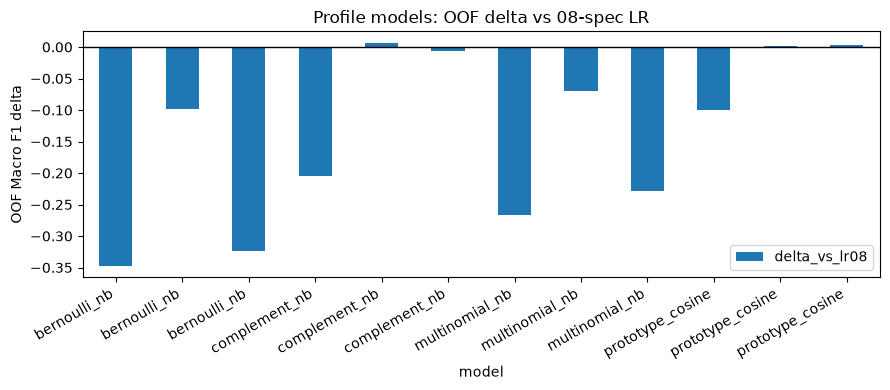

,model,fold,profile_fold_macro_f1,blend_0.25_fold_macro_f1,blend_0.50_fold_macro_f1
0,bernoulli_nb,3.0,0.134631,0.383023,0.157681
1,complement_nb,3.0,0.277631,0.489076,0.476017
2,multinomial_nb,3.0,0.214369,0.411301,0.252732
3,prototype_cosine,3.0,0.382683,0.483188,0.485352


In [3]:
summary = pd.read_csv(RESULT_DIR / f'{RUN_ID}_seed{SEED}_summary.csv')
folds = pd.read_csv(RESULT_DIR / f'{RUN_ID}_seed{SEED}_folds.csv')
assert summary.leakage_check.all() and summary.nan_as_mutation_count.eq(0).all()
display(summary.sort_values('delta_vs_lr08', ascending=False))
ax = summary[summary.model.ne('lr08_baseline')].plot.bar(
    x='model', y='delta_vs_lr08', figsize=(9, 4), title='Profile models: OOF delta vs 08-spec LR'
)
ax.axhline(0, color='black', linewidth=1); ax.set_ylabel('OOF Macro F1 delta')
plt.xticks(rotation=30, ha='right'); plt.tight_layout()
plt.savefig(RESULT_DIR / f'{RUN_ID}_seed{SEED}_delta.png', dpi=160)
plt.show()
display(folds.groupby('model', as_index=False).mean(numeric_only=True))
